In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('lego_sets.csv')

Understanding Data

In [63]:
df.head()

,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18457 entries, 0 to 18456
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   set_id          18457 non-null  object 
 1   name            18457 non-null  object 
 2   year            18457 non-null  int64  
 3   theme           18457 non-null  object 
 4   subtheme        14901 non-null  object 
 5   themeGroup      18455 non-null  object 
 6   category        18457 non-null  object 
 7   pieces          14533 non-null  float64
 8   minifigs        8399 non-null   float64
 9   agerange_min    6787 non-null   float64
 10  US_retailPrice  6982 non-null   float64
 11  bricksetURL     18457 non-null  object 
 12  thumbnailURL    17451 non-null  object 
 13  imageURL        17451 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 2.0+ MB


In [65]:
df.shape

(18457, 14)

In [66]:
df.describe()

,year,pieces,minifigs,agerange_min,US_retailPrice
count,18457.000000,14533.000000,8399.000000,6787.000000,6982.000000
mean,2007.960611,226.473749,2.663650,6.637542,37.534817
std,11.948666,469.988785,2.897857,2.780091,54.382712
min,1970.000000,0.000000,1.000000,1.000000,1.490000
25%,2001.000000,23.000000,1.000000,5.000000,9.990000
50%,2011.000000,70.000000,2.000000,6.000000,19.990000
75%,2017.000000,242.000000,3.000000,8.000000,39.990000
max,2022.000000,11695.000000,80.000000,18.000000,849.990000


Data Cleaning

In [67]:
df.isnull().sum()

set_id                0
name                  0
year                  0
theme                 0
subtheme           3556
themeGroup            2
category              0
pieces             3924
minifigs          10058
agerange_min      11670
US_retailPrice    11475
bricksetURL           0
thumbnailURL       1006
imageURL           1006
dtype: int64

In [68]:
df['US_retailPrice'] = df['US_retailPrice'].fillna(df['US_retailPrice'].median())
df['subtheme'] = df['subtheme'].fillna("Unknown")
df['themeGroup'] = df['themeGroup'].fillna("Unknown")
df['pieces'] = df['pieces'].fillna(df['pieces'].median())
df['minifigs'] = df['minifigs'].fillna(df['minifigs'].median())
df['agerange_min'] = df['agerange_min'].fillna(df['agerange_min'].median())
df.drop(['thumbnailURL', 'imageURL', 'bricksetURL'], axis=1, inplace=True)

In [69]:
df.isnull().sum()

set_id            0
name              0
year              0
theme             0
subtheme          0
themeGroup        0
category          0
pieces            0
minifigs          0
agerange_min      0
US_retailPrice    0
dtype: int64

In [70]:
df.drop_duplicates(inplace=True)

EDA

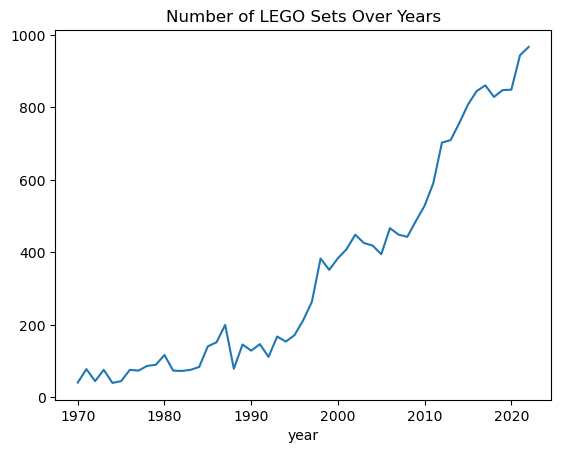

In [71]:
df['year'].value_counts().sort_index().plot(kind='line')
plt.title("Number of LEGO Sets Over Years")
plt.show()

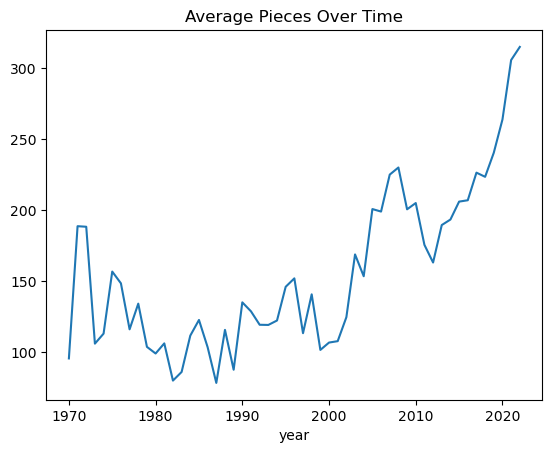

In [72]:
df.groupby('year')['pieces'].mean().plot()
plt.title("Average Pieces Over Time")
plt.show()

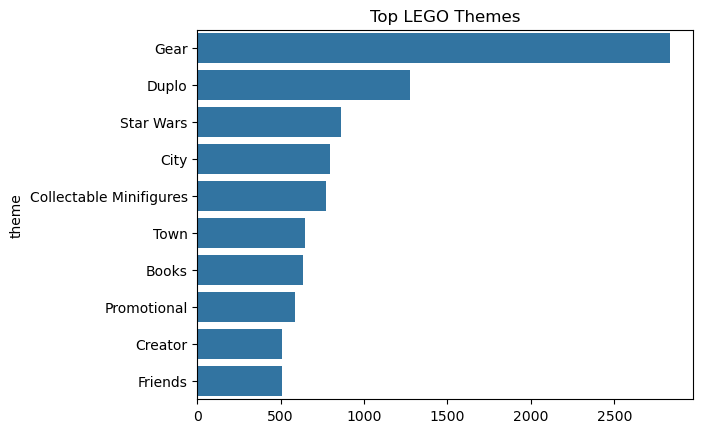

In [73]:
top_themes = df['theme'].value_counts().head(10)
sns.barplot(x=top_themes.values, y=top_themes.index)
plt.title("Top LEGO Themes")
plt.show()

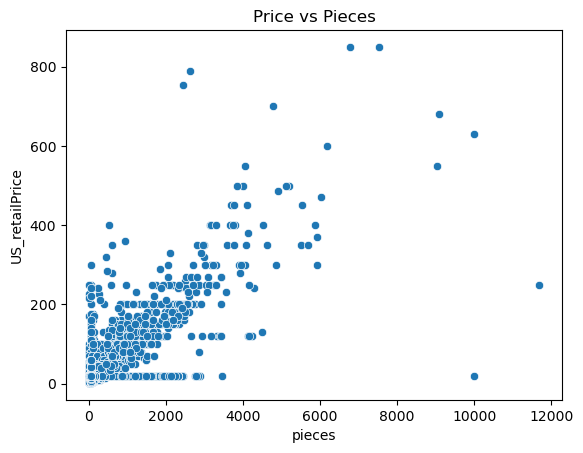

In [74]:
sns.scatterplot(x='pieces', y='US_retailPrice', data=df)
plt.title("Price vs Pieces")
plt.show()

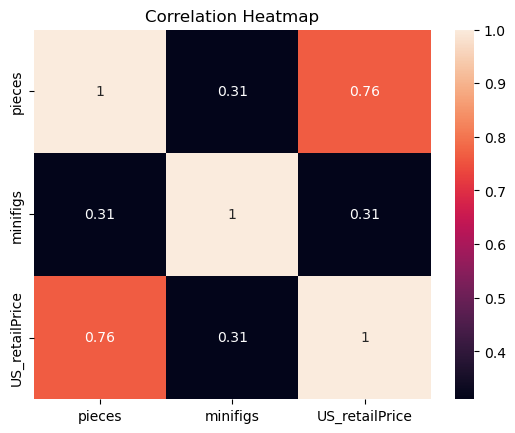

In [75]:
corr = df[['pieces', 'minifigs', 'US_retailPrice']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [76]:
df.nlargest(10, 'US_retailPrice')[['name', 'US_retailPrice']]

,name,US_retailPrice
13651,Millennium Falcon,849.99
17046,AT-AT,849.99
10584,Identity and Landscape Kit,789.99
10585,Connections Kit,754.99
15267,Imperial Star Destroyer,699.99
16559,Titanic,679.99
17500,Eiffel Tower,629.99
17934,The Razor Crest,599.99
15703,Colosseum,549.99
17962,Hulkbuster,549.99


ML Model

In [77]:
# Price per piece
df['price_per_piece'] = df['US_retailPrice'] / df['pieces']

In [78]:
X = df[['pieces', 'minifigs']]
y = df['US_retailPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Score:", model.score(X_test, y_test))

Model Score: 0.5663446558319134


1. How many LEGO sets since 1970? Is there a trend?

Total sets since 1970: 18457


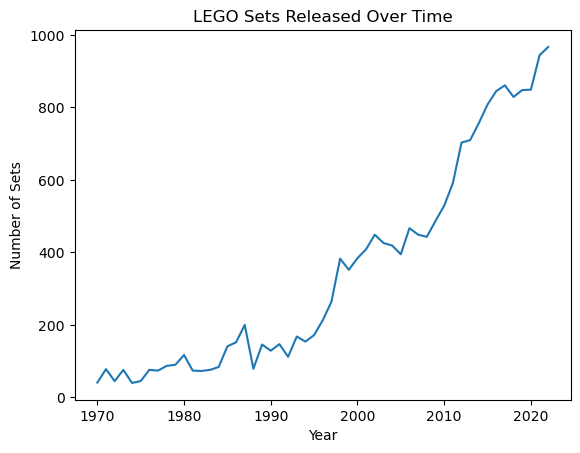

In [79]:
df_1970 = df[df['year'] >= 1970]

# Total count
total_sets = df_1970.shape[0]
print("Total sets since 1970:", total_sets)

# Trend
sets_per_year = df_1970['year'].value_counts().sort_index()

sets_per_year.plot()
plt.title("LEGO Sets Released Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Sets")
plt.show()

2. Relationship between price and number of pieces

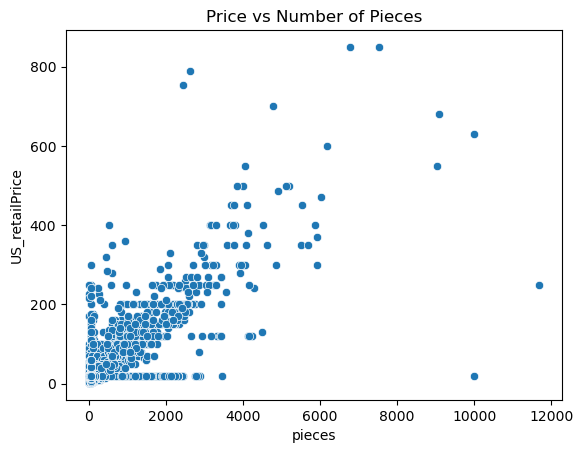

                  pieces  US_retailPrice
pieces          1.000000        0.764228
US_retailPrice  0.764228        1.000000


In [80]:
sns.scatterplot(x='pieces', y='US_retailPrice', data=df)

plt.title("Price vs Number of Pieces")
plt.show()

# Correlation
print(df[['pieces', 'US_retailPrice']].corr())

3. Most popular theme in each decade

In [81]:
df['decade'] = (df['year'] // 10) * 10

popular_themes = df.groupby(['decade', 'theme']).size().reset_index(name='count')

top_themes = popular_themes.loc[popular_themes.groupby('decade')['count'].idxmax()]

print(top_themes)

     decade     theme  count
10     1970  LEGOLAND    159
41     1980      Town    190
73     1990      Town    346
110    2000      Gear    892
174    2010      Gear   1306
249    2020      Gear    585


4. Are minifigures tied to licensed sets?

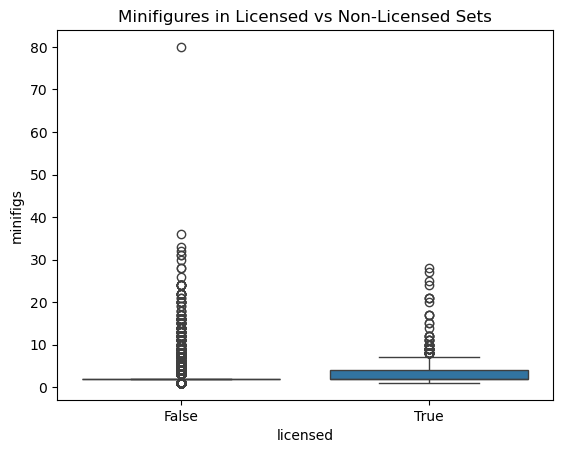

In [82]:
df['licensed'] = df['theme'].str.contains('Star Wars|Marvel|Harry Potter', na=False)

df.groupby('licensed')['minifigs'].mean()

sns.boxplot(x='licensed', y='minifigs', data=df)
plt.title("Minifigures in Licensed vs Non-Licensed Sets")
plt.show()